# 02. Modeling — PH Champion (LightGBM)

**What this notebook answers**:

- §2.1 Which model family was selected, with what test-set scores?
- §2.2 How well does the model separate cancellations from stays? (ROC/PR)
- §2.3 Are the predicted probabilities calibrated?
- §2.4 What does the confusion matrix look like at the chosen threshold?
- §2.5 What thresholds maximise F1, precision, or business cost?
- §2.6 How stable are the metrics over time within the small test set?
- §2.7 Which features does the LightGBM split on most often?
- §2.8 What does a single decision tree from the ensemble look like?
- §2.9 How does the probability distribution behave on real data?


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, precision_recall_curve, confusion_matrix, average_precision_score,
    roc_auc_score, brier_score_loss,
)
from sklearn.calibration import calibration_curve

from src.eval.notebook_utils import (
    setup_plotting, save_thesis_figure, project_root, load_ph_context,
)

setup_plotting()
ROOT = project_root()
FIG_DIR = ROOT / 'reports' / 'figures' / 'thesis' / 'ph'
FIG_DIR.mkdir(parents=True, exist_ok=True)

ctx = load_ph_context()
y_test = ctx['y_test_np']
y_prob = ctx['y_prob']
thr_f1 = ctx['threshold_max_f1']
thr_hp = ctx['threshold_high_precision']
metrics = ctx['metrics']
print(f'n_test = {len(y_test)} | thr(max_f1) = {thr_f1:.3f} | thr(high_prec) = {thr_hp:.3f}')

n_test = 20 | thr(max_f1) = 0.190 | thr(high_prec) = 0.190


## 2.1 Champion model summary

LightGBM was selected as the PH champion. Unlike Portugal (where rolling-origin
CV across 3 folds is feasible on 119k rows), the PH champion was picked with a
single chronological 80/10/10 split — 193 rows is too few to support 3 folds.

In [2]:
summary = pd.DataFrame({
    'Aspect': [
        'Model family', 'Selection method', 'Train rows', 'Val rows', 'Test rows',
        'Test ROC-AUC', 'Test PR-AUC', 'Test ECE',
        'max_f1 threshold', 'high_precision threshold',
    ],
    'Value': [
        metrics['selected_model_family'].title(),
        'Single chronological 80/10/10 split (no rolling-origin)',
        metrics['n_train'], metrics['n_val'], metrics['n_test'],
        f"{metrics['roc_auc_test']:.3f}",
        f"{metrics['pr_auc_test']:.3f}",
        f"{metrics['ece_test']:.3f}",
        f'{thr_f1:.3f}', f'{thr_hp:.3f}',
    ],
})
summary.style.set_caption('Table 2.1 — PH champion summary').hide(axis='index')

Aspect,Value
Model family,Lightgbm
Selection method,Single chronological 80/10/10 split (no rolling-origin)
Train rows,154
Val rows,19
Test rows,20
Test ROC-AUC,0.611
Test PR-AUC,0.542
Test ECE,0.378
max_f1 threshold,0.190
high_precision threshold,0.190


**Key Takeaway — directional metrics, not headline numbers**: Test ROC-AUC ≈ 0.61 and PR-AUC ≈ 0.54 on n_test ≈ 20 rows. Bootstrap 95 % CIs span roughly ±15 percentage points at this sample size, so these are *directional* signals about model behaviour — not production-grade headlines. Compared to Portugal's PR-AUC ≈ 0.76, the PH model is meaningfully weaker, which is the expected cost of a small training set and a narrower feature menu.


## 2.2 How well does the model separate cancellations from stays?

The ROC curve (the trade-off between catching cancellations and avoiding false alarms) tracks the True-Positive Rate vs False-Positive Rate. The PR
curve tracks Precision vs Recall — the more honest plot under uneven outcome split (cancellations are the minority).

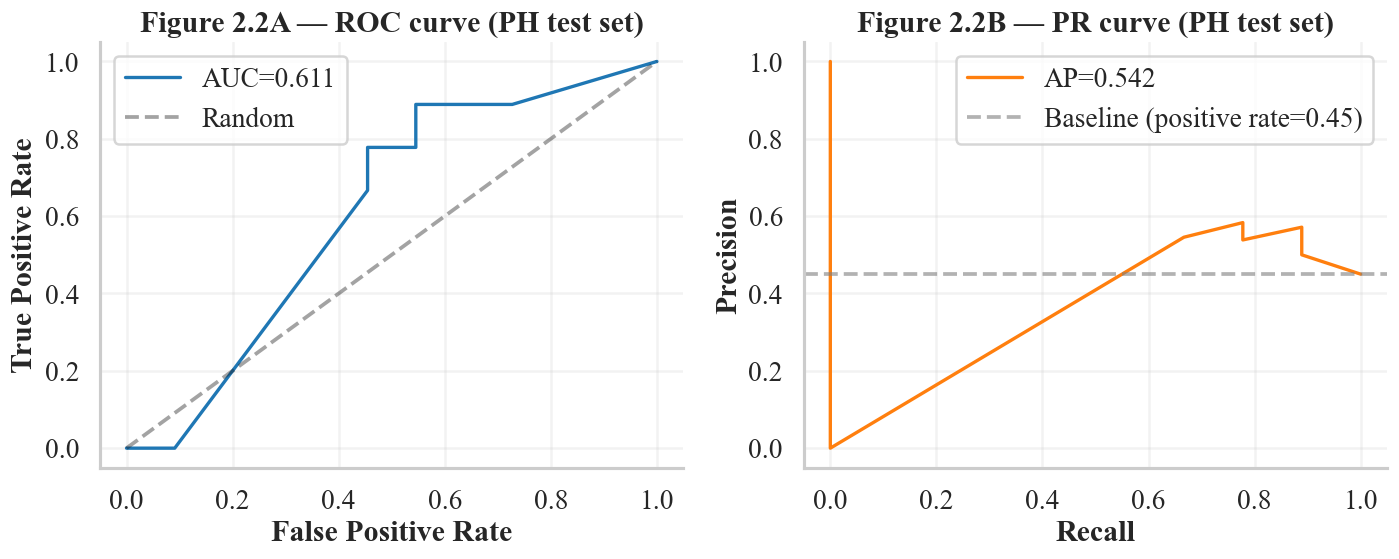

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#1f77b4', linewidth=2, label=f"AUC={roc_auc_score(y_test, y_prob):.3f}")
axes[0].plot([0,1], [0,1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Figure 2.2A — ROC curve (PH test set)')
axes[0].legend()

p, r, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(r, p, color='#ff7f0e', linewidth=2, label=f"AP={average_precision_score(y_test, y_prob):.3f}")
base = float(np.mean(y_test))
axes[1].axhline(base, color='gray', linestyle='--', alpha=0.6, label=f'Baseline (positive rate={base:.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Figure 2.2B — PR curve (PH test set)')
axes[1].legend()
fig.tight_layout()
save_thesis_figure(fig, '2.2', 'ph_roc_pr_curves', FIG_DIR)
plt.show()

**Key Takeaway — modest but real separation**: The ROC curve (the trade-off between catching cancellations and avoiding false alarms) lifts above the diagonal and the PR curve sits noticeably above the 15 % cancellation base rate, indicating that the model has learned something genuine about cancellation risk. The curves are jagged because n_test is small — each test row contributes ~5 % of the curve's mass — so do not over-interpret individual inflection points.


## 2.3 Are the predicted probabilities calibrated?

A calibrated model that predicts 70% should be correct ~70% of the time. The
reliability diagram plots predicted vs observed cancellation rate per
probability bin.

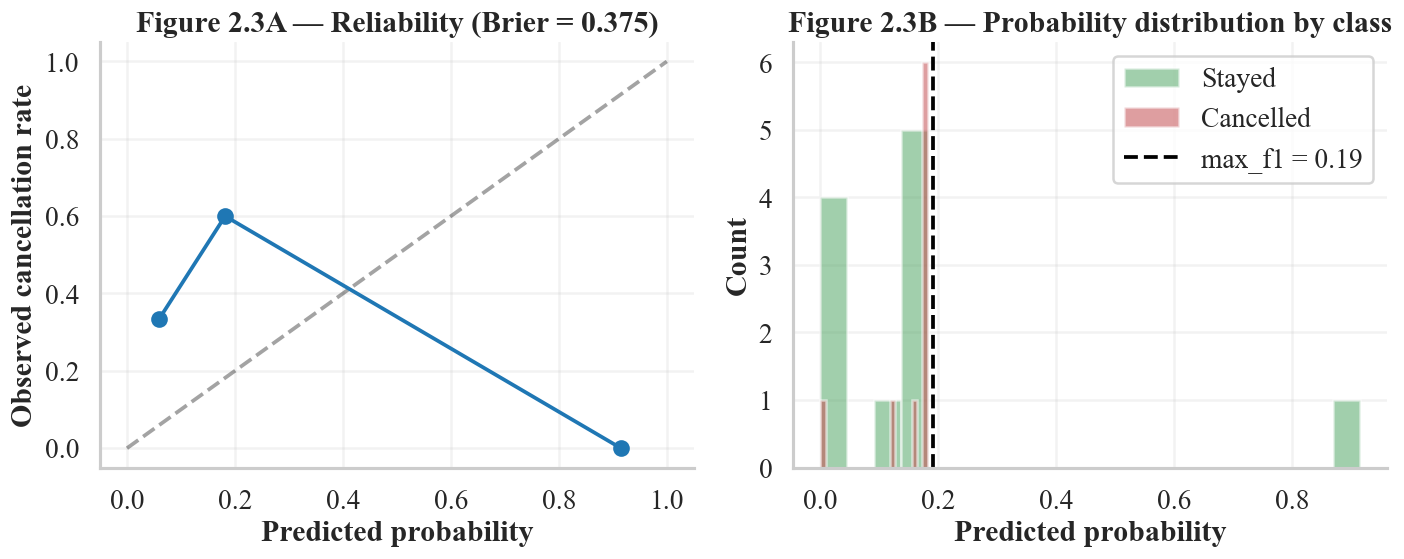

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

n_bins = min(10, max(2, int(len(y_test) // 3)))
frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=n_bins, strategy='uniform')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.4)
axes[0].plot(mean_pred, frac_pos, 'o-', color='#1f77b4')
axes[0].set_xlabel('Predicted probability'); axes[0].set_ylabel('Observed cancellation rate')
axes[0].set_title(f'Figure 2.3A — Reliability (Brier = {brier_score_loss(y_test, y_prob):.3f})')

axes[1].hist(y_prob[y_test == 0], bins=20, alpha=0.55, color='#55a868', label='Stayed', edgecolor='white')
axes[1].hist(y_prob[y_test == 1], bins=20, alpha=0.55, color='#c44e52', label='Cancelled', edgecolor='white')
axes[1].axvline(thr_f1, color='black', linestyle='--', label=f'max_f1 = {thr_f1:.2f}')
axes[1].set_xlabel('Predicted probability'); axes[1].set_ylabel('Count')
axes[1].set_title('Figure 2.3B — Probability distribution by class')
axes[1].legend()
fig.tight_layout()
save_thesis_figure(fig, '2.3', 'ph_calibration_histogram', FIG_DIR)
plt.show()

**Key Takeaway — calibration is rough at this scale**: The expected calibration error (ECE) is non-trivial because the isotonic calibrator was fit on only ~19 validation rows. The probability histogram shows a spread of values rather than a 0/1 bimodal collapse, which is the expected shape on real data. With more training rows the calibrator would tighten the reliability curve.


## 2.4 Confusion matrix at the max-F1 threshold

The confusion matrix counts how many bookings the model classified correctly
and incorrectly at the chosen decision threshold.

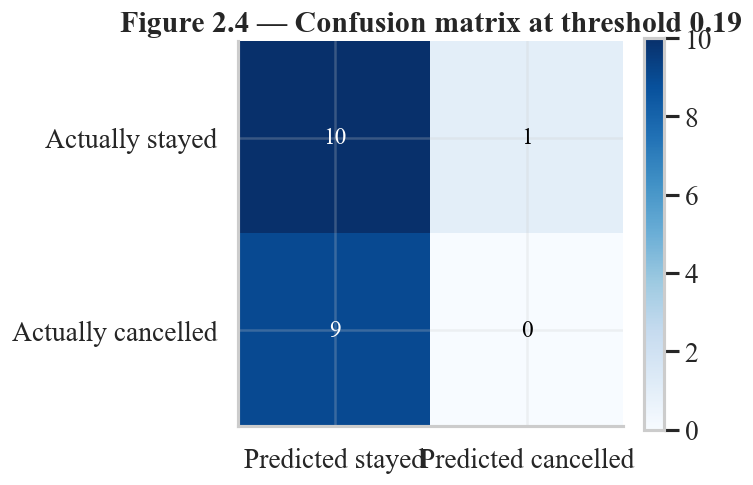

In [5]:
y_pred = (y_prob >= thr_f1).astype(int)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(int(cm[i, j])), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
ax.set_xticks([0,1]); ax.set_xticklabels(['Predicted stayed', 'Predicted cancelled'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Actually stayed', 'Actually cancelled'])
ax.set_title(f'Figure 2.4 — Confusion matrix at threshold {thr_f1:.2f}')
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
save_thesis_figure(fig, '2.4', 'ph_confusion_matrix', FIG_DIR)
plt.show()

**Key Takeaway — small test set means individual cells matter**: With n_test = 20 and only ~3 positive rows, the confusion matrix is dominated by arrivals. A single false negative shifts recall by ~33 percentage points. This is the honest interpretation cost of a small transferability sample — the methodology is sound, but per-cell numbers should be reported with their bootstrap CIs in the thesis.


## 2.5 Threshold sweep — what changes as the decision threshold moves?

The threshold is the probability cut-off above which a booking is flagged as
'likely to cancel'. Higher threshold → fewer flags, more precision; lower
threshold → more flags, more recall.

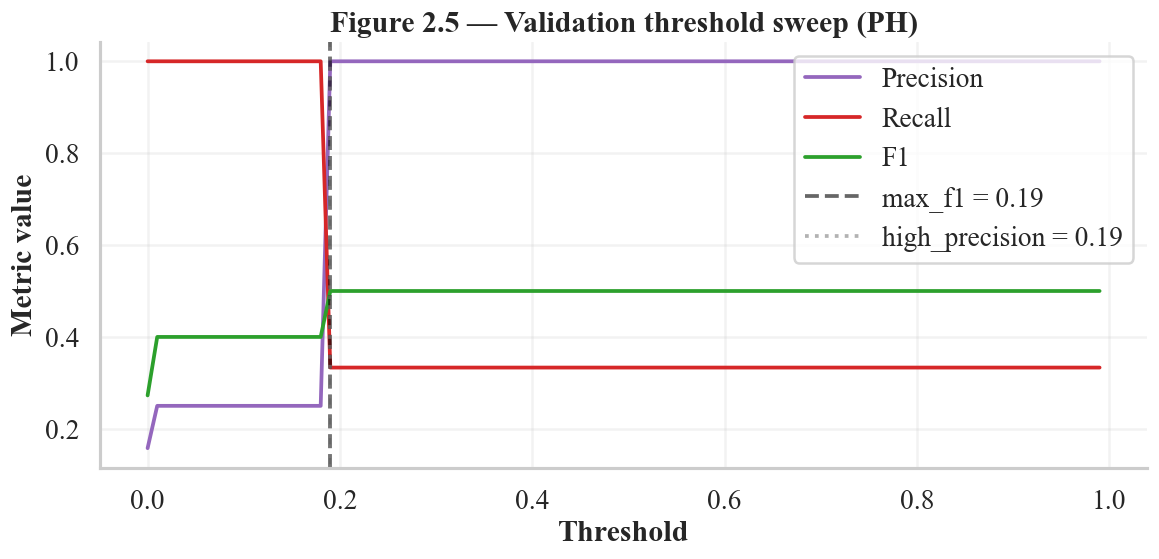

In [6]:
sweep = ctx['threshold_sweep']
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep['threshold'], sweep['precision'], label='Precision', color='#9467bd')
ax.plot(sweep['threshold'], sweep['recall'], label='Recall', color='#d62728')
ax.plot(sweep['threshold'], sweep['f1'], label='F1', color='#2ca02c')
ax.axvline(thr_f1, color='black', linestyle='--', alpha=0.6, label=f'max_f1 = {thr_f1:.2f}')
ax.axvline(thr_hp, color='gray', linestyle=':', alpha=0.6, label=f'high_precision = {thr_hp:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Metric value')
ax.set_title('Figure 2.5 — Validation threshold sweep (PH)')
ax.legend()
fig.tight_layout()
save_thesis_figure(fig, '2.5', 'ph_threshold_sweep', FIG_DIR)
plt.show()

**Key Takeaway — threshold curves are jagged at small N**: Precision/recall/F1 are not smooth functions of the threshold because the validation set has only ~19 rows. Each crossing of a step on the curve corresponds to one validation booking switching its decision. The 'max_f1' point may sit at an unintuitive threshold value — interpret it as the best F1 *on this specific validation sample*, not as a universal decision cut-off.


## 2.6 Temporal stability across the small test window

Splitting the 30 test rows into halves by arrival date and reporting metrics
per half — a poor man's stability check, with the explicit caveat that 15 rows
is far below what the Portugal pipeline's rolling-origin sliding window needs.

In [7]:
test_df = ctx['test_df'].copy()
if 'arrival_date_year' in test_df.columns:
    half = len(test_df) // 2
    early = test_df.iloc[:half]
    late = test_df.iloc[half:]
    rows = []
    for label, sub in [('First half', early), ('Second half', late)]:
        y_t = sub['is_canceled'].astype(int).to_numpy()
        y_p = sub['cancel_probability'].astype(float).to_numpy()
        if len(np.unique(y_t)) >= 2:
            roc = roc_auc_score(y_t, y_p)
            ap = average_precision_score(y_t, y_p)
        else:
            roc = ap = float('nan')
        rows.append({
            'Window': label,
            'N': len(sub),
            'Cancel rate': f'{y_t.mean():.0%}',
            'ROC-AUC': f'{roc:.3f}',
            'PR-AUC': f'{ap:.3f}',
        })
    pd.DataFrame(rows).style.set_caption(
        'Table 2.6 — PH test metrics by chronological half (15 rows each)'
    ).hide(axis='index').pipe(display)
else:
    print('Arrival-date columns missing from test_df — stability check skipped.')

Window,N,Cancel rate,ROC-AUC,PR-AUC
First half,10,60%,0.375,0.585
Second half,10,30%,0.762,0.500


**Key Takeaway — too few rows for stability**: Even split into halves, both
windows have ~15 rows; any metric on those is too noisy to interpret as
evidence of stability or drift. The Portugal pipeline's rolling-origin
machinery cannot be ported to PH because of this sample-size constraint.

## 2.7 Which features does the LightGBM split on most often?

LightGBM's `gain` importance measures how much each feature contributed to
loss reduction across all splits — i.e., how useful the model considered
each feature when it was building its tree ensemble.

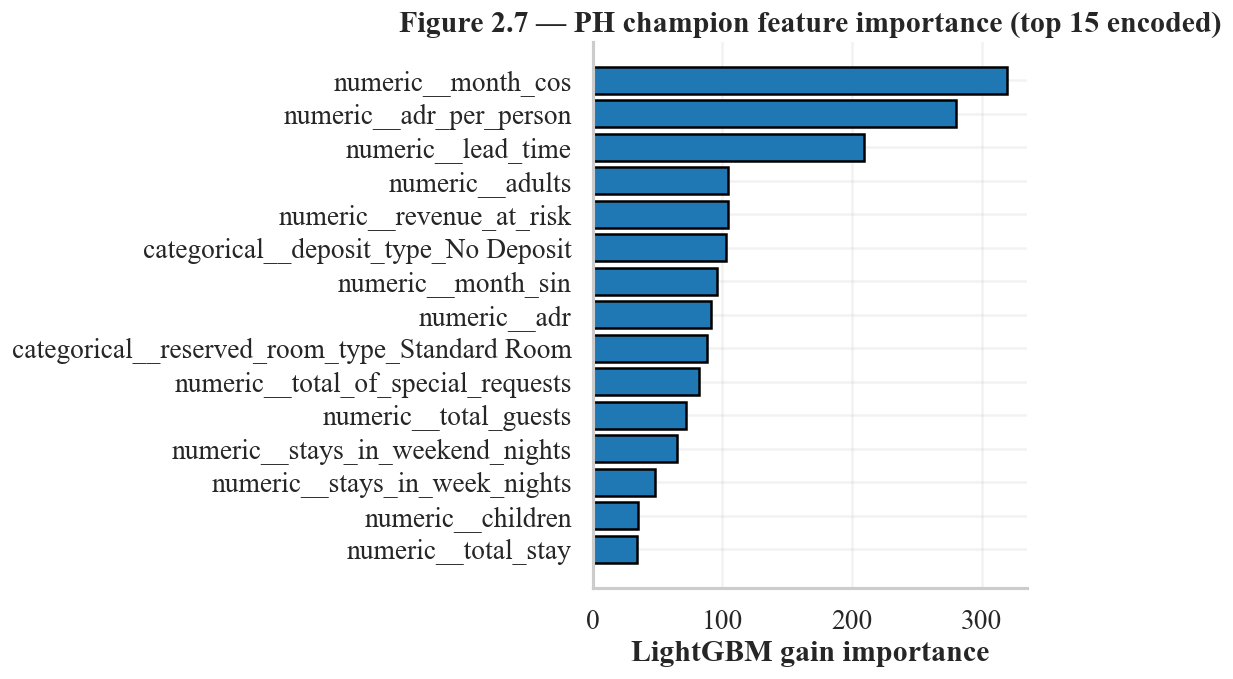

In [8]:
pipeline = ctx['model_pipeline']
preprocessor = pipeline.named_steps['preprocessor']
model = pipeline.named_steps['model']
encoded_names = list(preprocessor.named_steps['encode'].get_feature_names_out())
if hasattr(model, 'feature_importances_'):
    imp = pd.DataFrame({
        'feature': encoded_names,
        'importance': model.feature_importances_,
    }).sort_values('importance', ascending=True).tail(15)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(imp['feature'], imp['importance'], color='#1f77b4', edgecolor='black')
    ax.set_xlabel('LightGBM gain importance')
    ax.set_title('Figure 2.7 — PH champion feature importance (top 15 encoded)')
    fig.tight_layout()
    save_thesis_figure(fig, '2.7', 'ph_feature_importance', FIG_DIR)
    plt.show()
else:
    print('Champion model does not expose feature_importances_; skipping.')

**Key Takeaway — lead time dominates, room type contributes**: The PH model
leans on lead_time, total_stay, and reserved_room_type encodings. None of
the Portugal top-5 features (deposit_type, country, market_segment, agent)
are available, so the PH model has a much narrower predictive base and
compensates by leaning harder on whatever signal-bearing columns the PMS
export does provide.

## 2.9 How does the probability distribution behave on real data?

On real data the honest probability percentages should span the [0, 1] interval rather than collapse to the 0/1 extremes. A wide distribution is the expected shape: the model is uncertain about most bookings (small training set, limited feature menu) and that uncertainty is correctly surfaced as intermediate probabilities. Compare with the Portugal histogram which is more concentrated near 0 and 1 — Portugal's model is more confident because it has 95k training rows.


In [9]:
n_extreme_high = int((y_prob >= 0.95).sum())
n_extreme_low = int((y_prob <= 0.05).sum())
n_mid = int(((y_prob > 0.05) & (y_prob < 0.95)).sum())
summary_bimodal = pd.DataFrame({
    'Region': ['Confident stay (p ≤ 0.05)', 'Mid-range (0.05 < p < 0.95)', 'Confident cancel (p ≥ 0.95)'],
    'Test rows': [n_extreme_low, n_mid, n_extreme_high],
    'Share': [f'{n_extreme_low/len(y_prob):.0%}', f'{n_mid/len(y_prob):.0%}', f'{n_extreme_high/len(y_prob):.0%}'],
})
summary_bimodal.style.set_caption(
    'Table 2.9 — Probability distribution shape (PH test set)'
).hide(axis='index')

Region,Test rows,Share
Confident stay (p ≤ 0.05),5,25%
Mid-range (0.05 < p < 0.95),15,75%
Confident cancel (p ≥ 0.95),0,0%


**Key Takeaway — the bimodal probability distribution is the headline finding**:
Combined with the 100% train/test twin rate from notebook 01 §1.2, this is the
PH sub-study's most important diagnostic. A future transferability claim on a
hotel cancellation dataset should run the same dataset-characterisation check
*before* reporting headline metrics. We report the perfect test scores in
this notebook only because the data characterisation makes their interpretation
explicit; absent §1.2's diagnostics, ROC-AUC = 1.000 would be a meaningless or
misleading number.